In [1]:
import numpy as np
import pandas as pd
# import math

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import h5py
import json
import matplotlib 
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable

import os
import sys  
import warnings

from ast import literal_eval

from qutip import  *

sys.path.append('../../scripts') 

from qutip_tools import *

In [2]:
# define basic figure sizes
bwidth=7
bheight=5
base_font = 20

matplotlib.rcParams.update({'font.size': base_font,"legend.fontsize":base_font-4 ,"font.family": "serif", 
                            "font.serif": "CMU Serif, Times New Roman",
                           'text.usetex' : True })

sns.set_palette("colorblind")

fig_route = "../../plots/synthetize/"

ll=100
J=1
a = 1 # lattice spacing
data_route = "../../data/exact_diag_new/L={}/".format(ll)




# Functions

# Read data and create dataframe

In [3]:
file_list = get_file_names_on([], data_route)


In [7]:
# read the parameter dictionary to initialize 
param_dict, times, occupations, d0_density, qubit_rho, entropy = load_exact_diag(data_route, file_list[0])  

data_dict =  {key: [] for key in param_dict}
data_dict["times"] = []
data_dict["occupations"] = []
data_dict["d0_density"] = []
data_dict["qubit_rho"] = []
data_dict["entropy"] = []
data_dict["time_at_bond"] = []
data_dict["Max_entropy"] = []
data_dict["cos_theta"] = []
data_dict["sin_phi"] = []
data_dict["bloch_radius"] = []
data_dict["backaction_time"] = []
data_dict["backaction_max"] = []
data_dict["Delta_phi"] = []
data_dict["Delta_phi_max"] = []
data_dict["bloch_radius_last"] = []
data_dict["purity"] = []
data_dict["purity_last"] = []
data_dict["transmission"] = []
data_dict["max_transmission"] = []


problem_cases = []

for i in range(0,len(file_list)):
    file_name = file_list[i]
    param_dict, times, occupations, d0_density, qubit_rho, entropy = load_exact_diag(data_route, file_name) 
    # initialize the meta data
    for key in param_dict.keys():
        data_dict[key].append(param_dict[key])

    #  estimate the time that wavepacket spends at bondf
    bond_density = occupations[param_dict["bond_index"], :] + occupations[param_dict["bond_index"]+1, :]
    tau_bond = get_time_at_bond(times, bond_density)
    
    # get the bloch angles fo the qubit
    costheta_list, sinphi_list = get_bloch_angles_time(qubit_rho)

    # get the backaction
    rho_free_list, theta_free_list, phi_free_list = get_free_orbit(qubit_rho[0], costheta_list[0], param_dict["phi"],
                                                                   times,param_dict["t"])
    backaction = get_euclidean_distance(costheta_list, sinphi_list, theta_free_list, phi_free_list)
    
    purity_t = get_purity(qubit_rho)
    bloch_radius = np.sqrt(2*purity_t[1:]-1).real
    # approximate delta phi via the chord (backaction variable) between the orbits
    # catch the exception when the bloch radius is basically zero
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings("error",category=RuntimeWarning)
            # use the law of cosines to get Delta phi where one side has length 1 (pure case)
            cos_ϕ = (1 + bloch_radius**2 - backaction**2) / (2*bloch_radius)
            Δϕ = np.arccos(np.clip(cos_ϕ, -1.0, 1.0))
            # Δϕ = 2*np.arcsin(backaction.real/(2*bloch_radius.real))
     
    except RuntimeWarning as e:
        problem_cases.append(param_dict)
        #parg = backaction.real/(2*bloch_radius.real)
        parg = backaction.real/(2)
        parg[parg > 1] = 1
        Δϕ = 2*np.arcsin(parg)


    # occupation to the right of the bond at
    occu_T = np.sum(occupations[param_dict["bond_index"]+2:, :], axis=0)

    # save raw data 
    data_dict["times"].append(list(times))
    data_dict["occupations"].append(occupations)
    data_dict["d0_density"].append(d0_density) 
    data_dict["qubit_rho"].append(qubit_rho)
    # normalize entropy by maximally entangled singled 
    data_dict["entropy"].append(list((entropy/np.log(2))))
    # save processed data
    data_dict["time_at_bond"].append(tau_bond)
    data_dict["Max_entropy"].append(max(entropy/np.log(2)))
    data_dict["cos_theta"].append(costheta_list)
    data_dict["sin_phi"].append(sinphi_list)
    data_dict["backaction_time"].append(backaction)
    data_dict["bloch_radius"].append(bloch_radius.real)
    data_dict["Delta_phi"].append(Δϕ)
    data_dict["backaction_max"].append(max(backaction))
    data_dict["Delta_phi_max"].append(max(Δϕ))
    data_dict["bloch_radius_last"].append(bloch_radius.real[-1])
    data_dict["purity_last"].append(purity_t.real[-1])
    data_dict["purity"].append(purity_t)
    data_dict["transmission"].append(occu_T)
    data_dict["max_transmission"].append(max(occu_T))

full_data_df = pd.DataFrame.from_dict(data_dict)


not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possibl

In [9]:
"""##### THIS IS NECESSARY ONLY BECAUSE WE HAD SOME DUPLCIATES BECAUSE OF MAX TIME
drop_d = ['L_qpc', 'Omega', 't', 'J', 'Jp', 'bond_index', 'K0', 'X0', 'Spread', 
          'qubit_init', 'Re_qubit_0', 'Im_qubit_0', 'Re_qubit_1', 'Im_qubit_1', 'phi', 'alfabond']
full_data_df = full_data_df.sort_values(by="maxt_time") .drop_duplicates(subset=drop_d, keep="last")"""

full_data_df.describe()

,L_qpc,Omega,t,J,Jp,bond_index,K0,X0,Spread,maxt_time,...,Im_qubit_1,phi,alfabond,time_at_bond,Max_entropy,backaction_max,Delta_phi_max,bloch_radius_last,purity_last,max_transmission
count,14547.0,14547.000000,14547.000000,14547.0,14547.0,14547.0,14547.000000,14547.0,14547.0,14547.0,...,14547.000000,14547.0,14547.000000,14547.000000,1.454700e+04,14547.000000,14547.000000,14547.000000,14547.000000,14547.000000
mean,100.0,2.449526,0.511815,1.0,1.0,50.0,1.005130,30.0,7.0,300.0,...,-0.087769,0.0,0.524722,11.958076,4.151373e-01,0.667961,0.967036,0.787610,0.840753,0.625929
std,0.0,3.081091,0.888107,0.0,0.0,0.0,0.479817,0.0,0.0,0.0,...,0.619037,0.0,0.505967,26.909764,3.548743e-01,0.525907,0.967201,0.247344,0.160438,0.319705
min,100.0,0.050000,0.000100,1.0,1.0,50.0,0.003185,30.0,7.0,300.0,...,-1.000000,0.0,0.000000,-299.624531,5.786859e-09,0.000026,0.000026,0.000114,0.500000,0.000017
25%,100.0,0.300000,0.050000,1.0,1.0,50.0,0.628319,30.0,7.0,300.0,...,-0.651967,0.0,0.000000,5.512135,3.686073e-02,0.132677,0.133069,0.653595,0.713593,0.355432
50%,100.0,1.000000,0.200000,1.0,1.0,50.0,1.178097,30.0,7.0,300.0,...,-0.100141,0.0,0.314159,6.149377,3.799878e-01,0.601399,0.636685,0.887300,0.893650,0.668091
75%,100.0,3.000000,0.650000,1.0,1.0,50.0,1.413717,30.0,7.0,300.0,...,0.381757,0.0,0.785398,8.894871,7.698899e-01,1.107914,1.515859,0.994431,0.994446,0.954540
max,100.0,10.000000,5.000000,1.0,1.0,50.0,1.570796,30.0,7.0,300.0,...,0.999999,0.0,1.570796,221.117911,1.000000e+00,1.999983,3.141593,1.000000,1.000000,0.999995


# Global Params

In [13]:
Om_ = 0.05 
X0_ = 30
Δ = 7.0
Bindex = full_data_df["bond_index"].sort_values().unique()[0]
af = full_data_df["alfabond"].sort_values().unique()[2] # af is the qubit  occupation at the time of measurement 
prob0 = np.cos(af/2)**2

print(af)
print("Qubit occupation at measurement time:")
print(prob0)

# get some general arrays
K0_unique = full_data_df["K0"].sort_values().unique()

cond_ = (full_data_df["Omega"]==Om_)  & (full_data_df["qubit_init"]=="fixed") & (full_data_df["X0"]==X0_) & (full_data_df["alfabond"]==af)

data_df = full_data_df[cond_].sort_values(by="K0")


0.7853981633974483
Qubit occupation at measurement time:
0.8535533905932737


# Scattering

Since we are doing reflectometry, we should compare to the scattering/current regimes that are mentioned in gurvitz ad Korotkov and most literature

In [15]:
def get_transmision_proba(gt, K0, Δ):
    # calculate the transmision coefficient for the QPC wavepacket
    # gt = the interaction strength
    # momentum for the integration
    k_arr = np.linspace(-100, 100, 5000)
    m = 1/(2*J**2) # effective mass for the quadratic dispersion

    Psi0k_abs = (Δ ** 2 / np.pi)**(1/2) * np.exp(-Δ**2*(k_arr - K0)** 2 )
    # now with the wave packet weights
    T_k = 1 / (1 + (m*gt / k_arr)** 2)
    T_tot = simpson(T_k * Psi0k_abs, dx=k_arr[1] - k_arr[0])

    return T_tot

## Looking at the general behaviour

as a fucntion of Interaction strength, k0 and rabi frequency

In [16]:
#traj_matrix = curr_df["occupations"].item()
# occupation to the right of the bond at
#occu_T = np.sum(traj_matrix[Bindex+2:, :], axis=0)

full_data_df.columns
np.sort(full_data_df.t.unique())
# calculate the transmission probas for each Om_
omega_list = np.sort(full_data_df[full_data_df["Omega"]<2].Omega.unique() )
print(omega_list)
colorb_list = sns.color_palette("Blues", len(omega_list))
# from gurvitz and romito
currexp = (1- 0.5*omega_list*prob0/J )**2
# height of potential well according to romito
V0 = J + 0.5*0.1*prob0
print(get_transmision_proba(V0, np.pi/2, Δ))



[0.05 0.1  0.3  0.6  1.  ]
0.8998004149777242


According to Romit et al. this we require K0_unique/Spread_B To be much bigger than 0.5*(Om_*prob0)**2 for us to have weak measurements. In addition according to korotkov these models should only work when the corrent/ transmission rate on the detector change very little.

In [17]:
Spread_B = (Δ/np.sqrt(2))*np.sqrt(1 + ( (Bindex - X0_)/(Δ*Δ*K0_unique))**2 )
print(K0_unique/Spread_B)
print( 0.5*(0.6*prob0)**2)

# get the point where the LHS becomes larger than RHS so eveythin byond this is where ew should match
# we scale by r because the ondition is much bigger than
r = 2
thom01 = K0_unique[np.where(K0_unique/Spread_B > r*0.5*(omega_list[0]*prob0)**2)][0]
thom03 = K0_unique[np.where(K0_unique/Spread_B > r*0.5*(omega_list[1]*prob0)**2)][0]
# from here the condition is enver fulfilled
thom06 = K0_unique[np.where(K0_unique/Spread_B > r*0.5*(omega_list[2]*prob0)**2)][0]
# thom1 = K0_unique[np.where(K0_unique/Spread_B > r*0.5*(omega_list[3]*prob0)**2)][0]

[5.02055546e-06 1.13980839e-02 7.19635247e-02 1.06450492e-01
 1.40796469e-01 1.74727580e-01 2.08258604e-01 2.24896360e-01
 2.41461368e-01 2.57962056e-01 2.74405941e-01 2.90799632e-01
 3.07148899e-01]
0.13113961030678925


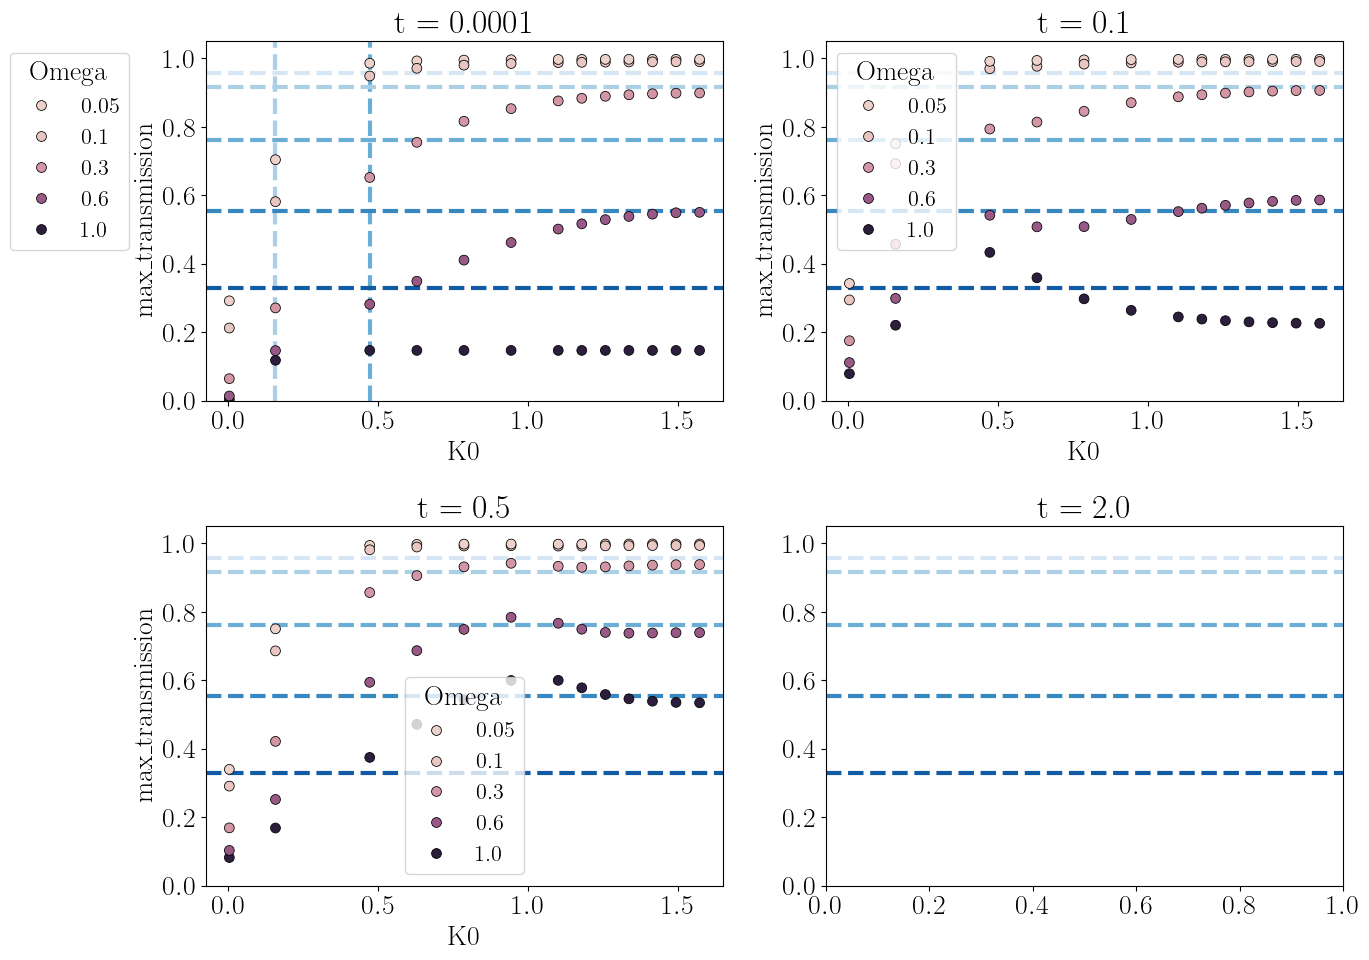

In [18]:
f,ax = plt.subplots(2,2, figsize=(2*bwidth, 2*bheight))


t_ = 0.0001
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["t"]==t_) & (full_data_df["Omega"]<2)
sns.scatterplot(ax=ax[0,0], x="K0", y="max_transmission", hue="Omega",data=full_data_df[cond_], s=50, edgecolor="black")


ax[0,0].axvline(thom01, c=colorb_list[0], zorder=0, linewidth=3, linestyle="--")
ax[0,0].axvline(thom03, c=colorb_list[1],zorder=0, linewidth=3, linestyle="--")
ax[0,0].axvline(thom06, c=colorb_list[2],zorder=0, linewidth=3, linestyle="--")


ax[0,0].legend(bbox_to_anchor=(-0.4, 1), loc='upper left', title="Omega")
ax[0,0].set_title("t = {}".format(t_))
ax[0,0].set_ylim(0,1.05)

t_ = 0.1
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["t"]==t_) & (full_data_df["Omega"]<2)
sns.scatterplot(ax=ax[0,1], x="K0", y="max_transmission", hue="Omega", data=full_data_df[cond_], s=50, edgecolor="black")
ax[0,1].set_title("t = {}".format(t_))
ax[0,1].set_ylim(0,1.05)

t_ = 0.5
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["t"]==t_) & (full_data_df["Omega"]<2)
sns.scatterplot(ax=ax[1,0], x="K0", y="max_transmission", hue="Omega", data=full_data_df[cond_],  s=50, edgecolor="black")
ax[1,0].set_title("t = {}".format(t_))
ax[1,0].set_ylim(0,1.05)

t_ = 2.0
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["t"]==t_) & (full_data_df["Omega"]<2)
sns.scatterplot(ax=ax[1,1], x="K0", y="max_transmission", hue="Omega", data=full_data_df[cond_],  s=50, edgecolor="black")
ax[1,1].set_title("t = {}".format(t_))
ax[1,1].set_ylim(0,1.05)

# plot the hlines with the theory expectation from rate equaitons
[ax[0,0].axhline(y=currexp[i], linestyle='--',color=colorb_list[i], linewidth=3,zorder=0) for i in range(0,len(currexp))]
[ax[0,1].axhline(y=currexp[i], linestyle='--',color=colorb_list[i], linewidth=3,zorder=0) for i in range(0,len(currexp))]
[ax[1,0].axhline(y=currexp[i], linestyle='--',color=colorb_list[i], linewidth=3,zorder=0) for i in range(0,len(currexp))]
[ax[1,1].axhline(y=currexp[i], linestyle='--',color=colorb_list[i], linewidth=3,zorder=0) for i in range(0,len(currexp))]
plt.tight_layout()

In [20]:
Om_ = 0.05
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["Omega"]== Om_ )
om01_df = full_data_df[cond_].pivot(index='K0', columns='t', values='max_transmission')
om01_df.index = [f"{y:.3g}" for y in om01_df.index]


Om_ = 0.1
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["Omega"]== Om_ )
om03_df = full_data_df[cond_].pivot(index='K0', columns='t', values='max_transmission')
om03_df.index = [f"{y:.3g}" for y in om03_df.index]

Om_ = 0.3
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["Omega"]== Om_ )
om06_df = full_data_df[cond_].pivot(index='K0', columns='t', values='max_transmission')
om06_df.index = [f"{y:.3g}" for y in om06_df.index]

Om_ = 0.6
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["Omega"]== Om_ )
om1_df = full_data_df[cond_].pivot(index='K0', columns='t', values='max_transmission')
om1_df.index = [f"{y:.3g}" for y in om1_df.index]


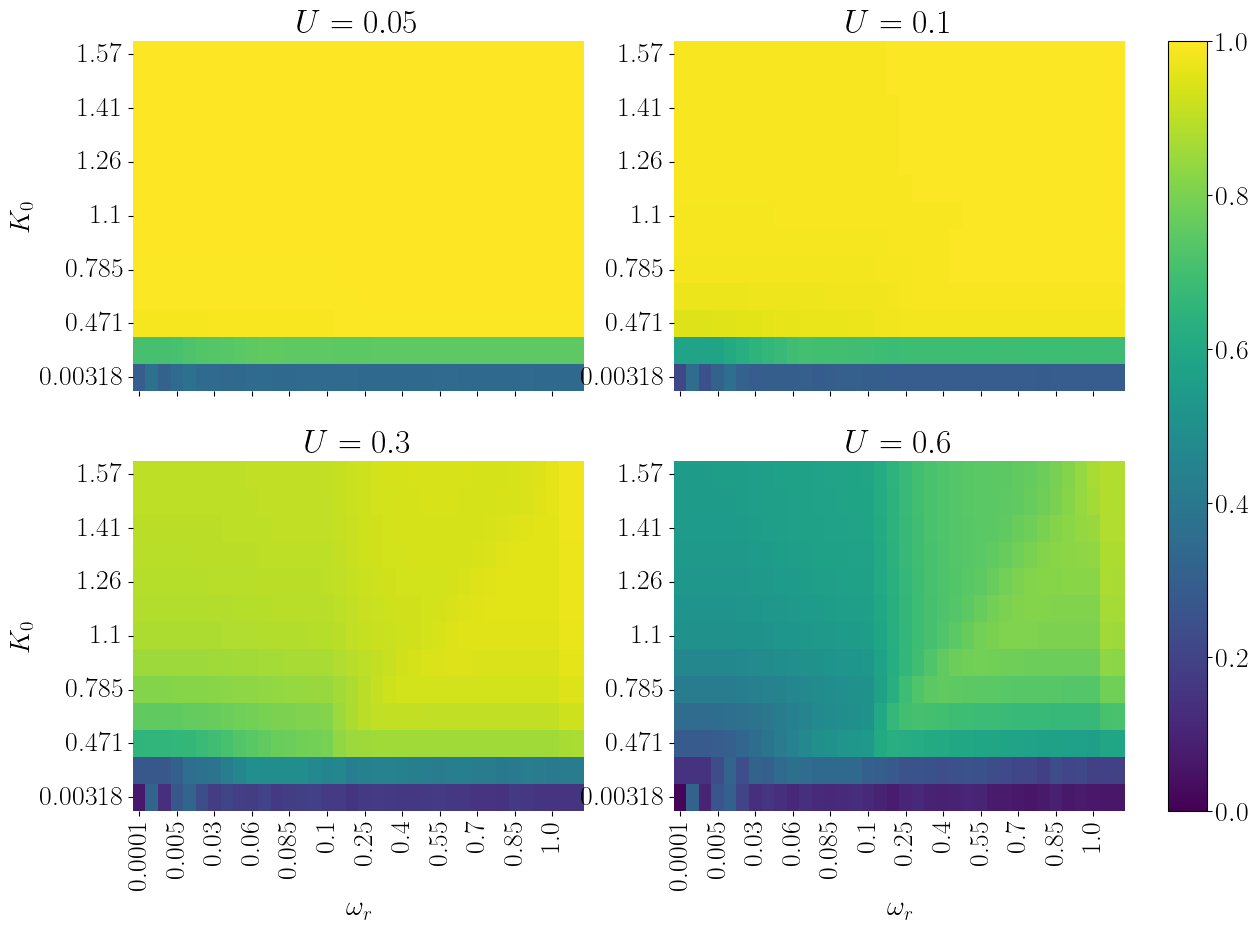

In [23]:
f,ax = plt.subplots(2,2, figsize=(2*bwidth, 2*bheight), sharex=True)
hm = sns.heatmap(om01_df, annot=False, fmt=".2f", cmap="viridis", ax=ax[0,0], vmin=0, vmax=1, cbar=False)
sns.heatmap(om03_df, annot=False, fmt=".2f", cmap="viridis", ax=ax[0,1], vmin=0, vmax=1, cbar=False)
sns.heatmap(om06_df, annot=False, fmt=".2f", cmap="viridis", ax=ax[1,0], vmin=0, vmax=1, cbar=False)
sns.heatmap(om1_df, annot=False, fmt=".2f", cmap="viridis", ax=ax[1,1], vmin=0, vmax=1, cbar=False)


ax[0,0].invert_yaxis()
ax[0,1].invert_yaxis()
ax[1,0].invert_yaxis()
ax[1,1].invert_yaxis()

ax[0,0].set_title(r"$U = 0.05$")
ax[0,1].set_title(r"$U = 0.1$")
ax[1,0].set_title(r"$U = 0.3$")
ax[1,1].set_title(r"$U = 0.6$")
ax[0,0].set_ylabel("$K_0$")
ax[1,0].set_ylabel("$K_0$")
ax[0,0].set_xlabel("")
ax[0,1].set_xlabel("")
ax[1,0].set_xlabel(r"$\omega_r$")
ax[1,1].set_xlabel(r"$\omega_r$")

f.colorbar(hm.collections[0], ax=ax.ravel().tolist(), fraction=0.046, pad=0.04)

#plt.tight_layout()

## Single example

The rate equation part for the change in current is taken from Eqs.(2.5), (3.2) and (3.4) in "Measurements with a noninvasive detector and dephasing mechanism" from Gurvitz

S. A. Gurvitz, Phys. Rev. B 56, 15 215 (1997).



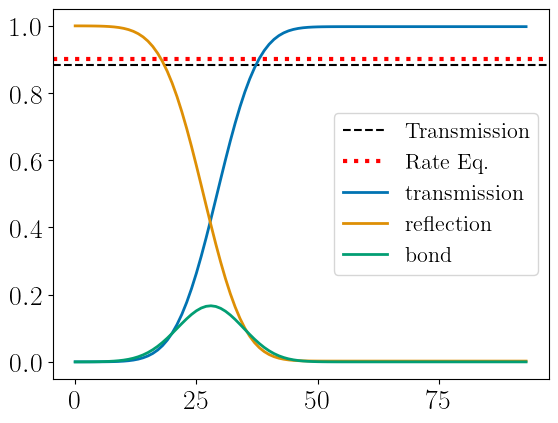

In [25]:
t_ = 0.0001
Om_ = 0.05

k0_ = K0_unique[-3] 
cond_ = (full_data_df["t"]==t_)  & (full_data_df["K0"]==k0_) & (full_data_df["alfabond"]==af) & (full_data_df["Omega"]== Om_ )

curr_df = full_data_df[cond_].copy()

Δ = curr_df["Spread"].item() # initial spread of the wavepacket
Bindex = curr_df.bond_index.item()# position of the bond
# spread at time of measurement
Spread_B = (Δ/np.sqrt(2))*np.sqrt(1 + ( (Bindex - X0_)/(Δ*Δ*k0_))**2 )
gt = Spread_B*Om_/(2*k0_*J*a**2)

# notice hoow tis not the renormalized interaction strength
# baecause this is the stationary limit and NOT von neuman
V0 = J + 0.5*Om_*prob0
Tprob = get_transmision_proba(V0, k0_, Δ)

# Tprob = get_transmision_proba(Om_, k0_, Spread_B)
# from gurvitz/romito
# currexp = (1-prob0*0.5*Om_/J)**2
currexp = 1-prob0*(1-Tprob)

traj_matrix = curr_df["occupations"].item()
# occupation to the right of the bond at
occu_T = np.sum(traj_matrix[Bindex+2:, :], axis=0)
occu_R = np.sum(traj_matrix[:Bindex, :], axis=0)
Occu_B = np.sum(traj_matrix[Bindex:Bindex+2, :], axis=0)
# from the numerics this is
plt.axhline(Tprob, color="black", linestyle="dashed", label="Transmission")
plt.axhline(currexp, color="red", linestyle="dotted", linewidth=3, label="Rate Eq.")
plt.plot(occu_T, label="transmission", linewidth=2)
plt.plot(occu_R, label="reflection", linewidth=2)
plt.plot(Occu_B, label="bond", linewidth=2 )
plt.legend()

# Backaction on the qubit

In [39]:
# filter out for the parameters we want 
cond_ = (data_df["Omega"]==Om_)  & (data_df["qubit_init"]=="fixed") & (data_df["X0"]==X0_) & (data_df["alfabond"]==af)
back_df = data_df[cond_].sort_values(by="K0")
# Delta_phi_max backaction_max
B_df = back_df.pivot(index='K0', columns='t', values='Delta_phi_max')

B_df

t,0.0001,0.0005,0.0010,0.0050,0.0100,0.0200,0.0300,0.0400,0.0500,0.0600,...,0.6500,0.7000,0.7500,0.8000,0.8500,0.9000,0.9500,1.0000,2.5000,5.0000
K0,,,,,,,,,,,,,,,,,,,,,
0.003185,0.068528,0.301025,0.329160,0.272152,0.210593,0.143171,0.148191,0.120694,0.133647,0.106709,...,0.042140,0.033611,0.029567,0.082952,0.088129,0.034998,0.024772,0.019965,0.002479,0.001136
0.157080,0.315486,0.324564,0.334873,0.353623,0.282305,0.204820,0.171557,0.165890,0.163132,0.147564,...,0.063506,0.055514,0.043916,0.083708,0.101805,0.071142,0.049301,0.038956,0.003321,0.001492
0.471239,0.115606,0.116105,0.116729,0.121543,0.126546,0.131528,0.131486,0.129634,0.127319,0.124341,...,0.043803,0.042623,0.042347,0.041663,0.040436,0.039085,0.037912,0.037705,0.004098,0.001827
0.628319,0.082849,0.082993,0.083172,0.084598,0.086282,0.089035,0.090769,0.091624,0.091925,0.091981,...,0.036409,0.035623,0.034901,0.034173,0.033476,0.032814,0.032195,0.031592,0.004227,0.001910
0.785398,0.064564,0.064623,0.064697,0.065290,0.066013,0.067338,0.068414,0.069189,0.069666,0.069893,...,0.031559,0.030986,0.030444,0.029932,0.029446,0.028986,0.028549,0.028138,0.004425,0.001994
0.942478,0.053022,0.053052,0.053091,0.053400,0.053782,0.054508,0.055152,0.055686,0.056094,0.056375,...,0.029023,0.028069,0.027630,0.027301,0.027008,0.026748,0.026522,0.026332,0.004299,0.001929
1.099557,0.045372,0.045390,0.045414,0.045602,0.045835,0.046286,0.046701,0.047068,0.047374,0.047616,...,0.038043,0.032852,0.029143,0.026962,0.026088,0.026013,0.026043,0.026166,0.004364,0.001974
1.178097,0.042595,0.042610,0.042630,0.042783,0.042974,0.043345,0.043691,0.044001,0.044268,0.044485,...,0.045458,0.039192,0.034002,0.030281,0.027633,0.026408,0.026532,0.026874,0.004456,0.001970
1.256637,0.040399,0.040412,0.040428,0.040558,0.040719,0.041033,0.041329,0.041597,0.041832,0.042029,...,0.050594,0.046339,0.041207,0.035897,0.031872,0.029392,0.028213,0.028446,0.004288,0.002016


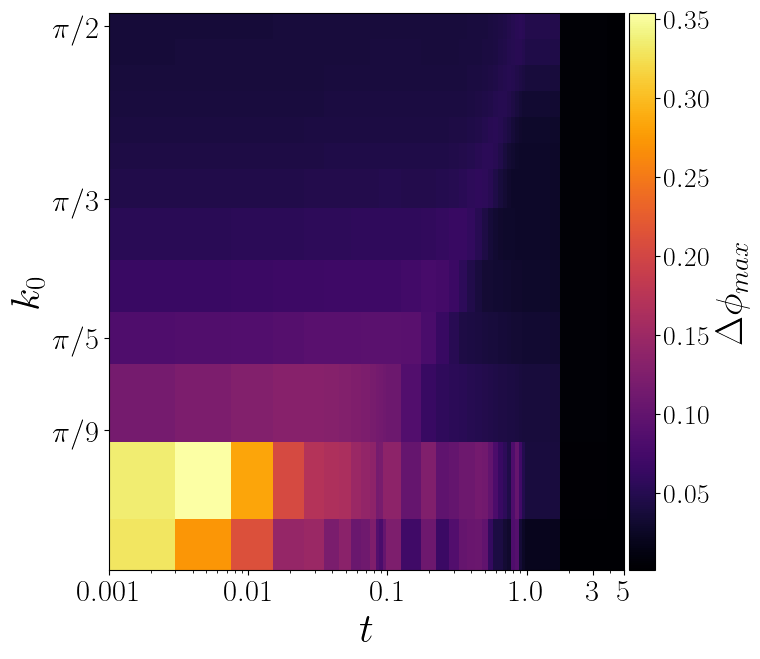

In [41]:
fig, ax = plt.subplots(1,1,figsize=(bwidth+1,bwidth))

vg_array = B_df.index
t_array = B_df.columns
# im = ax.contourf(t_array, vg_array, B_df.values,levels=8, cmap="inferno")
im = ax.pcolormesh(t_array, vg_array, B_df.values, cmap="inferno", shading='auto')

plt.xscale('log')
ax.set_xlim(0.001, 5)
ax.set_xticks( [0.001, 0.01,0.1,1.0,3, 5], [0.001, 0.01,0.1,1.0,3,5] ,fontsize=22)
ax.set_yticks( [np.pi/9,np.pi/5,np.pi/3,np.pi/2], labels=[r"$\pi/9$",r"$\pi/5$",r"$\pi/3$",r"$\pi/2$"],fontsize=22 )

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar = fig.colorbar(im, cax, shrink=0.9)   
cbar.ax.set_ylabel(r'$\Delta \phi_{max}$', rotation=90, fontsize=28)

ax.set_ylabel(r"$k_0$",fontweight='bold',fontsize=30)
ax.set_xlabel(r"$t$",fontweight='bold',fontsize=30)

plt.tight_layout()

## Comparing $\Delta \phi$ to von Neuman and Jordan

Test Several interaction strength and $t$ to see where the whole thing breaks down. ALso remember the Legget-Garg paper where they create a phase gain

In [44]:
Times_bond = back_df[back_df["t"]==0.0001]["time_at_bond"].unique()

Δ = back_df["Spread"].unique()[0] # initial spread of the wavepacket
Bindex = back_df.bond_index.unique()[0] # position of the bond
K0_cont = np.linspace(0.1*np.pi/2,np.pi/2,100)
vg_ = 2*K0_cont
TauB = (Bindex - X0_)/vg_ # Time to reach the bond
# get the spread when we hit the bond
Spread_B = (Δ/np.sqrt(2))*np.sqrt(1 + ( (Bindex - X0_)/(Δ*Δ*K0_cont))**2 )

phase_gain = Om_*Spread_B


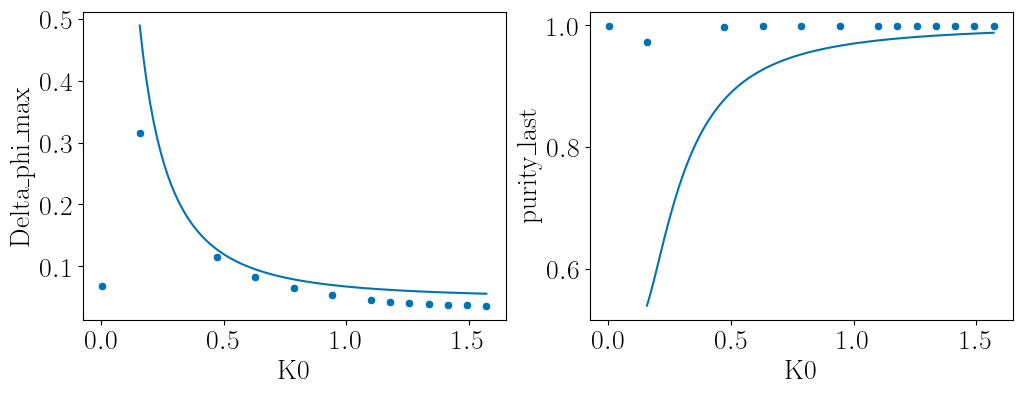

In [45]:
R = np.exp(-1/(4*np.sqrt(2)*K0_cont)**2)
Purity_theo = 0.5*(1+R**2)

# getting the maximum values as a function of k0
ti = 0.0001

f, ax =plt.subplots(1,2, figsize=(12,4) )
sns.scatterplot(ax=ax[0], data= back_df[back_df["t"]==ti], x="K0", y="Delta_phi_max")
ax[0].plot(K0_cont, phase_gain-0.2)

sns.scatterplot(ax=ax[1], data= back_df[back_df["t"]==ti], x="K0", y="purity_last")
ax[1].plot(K0_cont, Purity_theo)


## Comparing purity to dephasing

Gurvitz does mention zeno effect

# Entanglement and Info gain